In [55]:
import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

PATH = "oofs/"  # folder where you put all the CSV pairs
true = pd.read_csv('dataset/training_data.csv', header=None,
                   delimiter="\t", names=["labels", "text"])["labels"].values

files = []
x_train = []
x_test = []

for fname in os.listdir(PATH):
    if fname.endswith('.csv') and '_oof' not in fname: # Not _oof file 
        base = fname[:-4] # Get both csv files
        oof_path = os.path.join(PATH, base + '_oof.csv')
        pred_path = os.path.join(PATH, fname)
        if not os.path.exists(oof_path):
            continue
        print(f"Loading {base}")
        x_train.append(pd.read_csv(oof_path).values.flatten())
        x_test.append(pd.read_csv(pred_path).values.flatten())
        files.append(base)

x_train = np.stack(x_train).T  # shape: (n_train, n_models)
x_test = np.stack(x_test).T    # shape: (n_test, n_models)

X_train, X_val, y_train, y_val = train_test_split(x_train, true, test_size=0.2, random_state=42)

estimators = [
    ('lr', LogisticRegression()),
    ('nb', MultinomialNB()),
    ('rf', RandomForestClassifier())
]
meta = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
meta.fit(X_train, y_train)


# Meta-learner
#meta = LogisticRegression()
#meta.fit(x_train, true)

final_probs = meta.predict_proba(x_test)[:, 1]
final_preds = (final_probs >= 0.5).astype(int)

oof_preds = (meta.predict_proba(x_train)[:, 1] >= 0.5).astype(int)
print(f"Ensemble OOF accuracy: {accuracy_score(true, oof_preds):.4f}")
print(f"Ensemble OOF F1: {f1_score(true, oof_preds):.4f}")

Loading MLP_medium_mpnet
Loading LogisticRegression_TFIDF
Loading LinearSVC_TFIDF_bigram
Loading LR_mpnet
Loading LR_MiniLM_C10
Loading LR_MiniLM_C0.1
Loading LinearSVC_mpnet
Loading LR_TFIDF_bigram
Loading MultinomialNB_BOW
Loading RandomForestClassifier_TFIDF
Loading LR_TFIDF_100k
Loading LinearSVC_TFIDF_100k
Loading LSTM_small
Loading MLP_small_MiniLM
Loading MLP_medium_MiniLM
Loading MultinomialNB
Loading RandomForestClassifier
Loading LSTM_deep
Loading LR_TFIDF_char
Loading LR_MiniLM_C0.01
Loading MultinomialNB_TFIDF
Loading MLP_small_mpnet
Loading Ridge_MiniLM
Loading LinearSVC_TFIDF_char
Loading GradientBoostingClassifier
Loading SGD_log_MiniLM
Loading DistilBERT_2
Loading NB_TFIDF_char
Loading RandomForestClassifier_BOW
Loading LinearSVC_MiniLM
Loading DistilBERT_1
Loading DistilBERT_3ep_1
Loading StackingClassifier
Loading LogisticRegression_BOW
Loading LogisticRegression
Ensemble OOF accuracy: 0.9967
Ensemble OOF F1: 0.9966


In [49]:
test_data = pd.read_csv('dataset/testing_data.csv', header=None, delimiter="\t", names=["label","text"])
test_data["label"] = final_preds
test_data.to_csv("final_submission.csv", index=False, sep="\t", header=False)

MLP_medium_mpnet                              acc=0.9557  f1=0.9544
LogisticRegression_TFIDF                      acc=0.9396  f1=0.9386
LinearSVC_TFIDF_bigram                        acc=0.9512  f1=0.9500
LR_mpnet                                      acc=0.9392  f1=0.9376
LR_MiniLM_C10                                 acc=0.9325  f1=0.9312
LR_MiniLM_C0.1                                acc=0.9106  f1=0.9092
LinearSVC_mpnet                               acc=0.9481  f1=0.9469
LR_TFIDF_bigram                               acc=0.9412  f1=0.9401
MultinomialNB_BOW                             acc=0.9402  f1=0.9379
RandomForestClassifier_TFIDF                  acc=0.9310  f1=0.9293
LR_TFIDF_100k                                 acc=0.9396  f1=0.9386
LinearSVC_TFIDF_100k                          acc=0.9476  f1=0.9465
LSTM_small                                    acc=0.9443  f1=0.9432
MLP_small_MiniLM                              acc=0.9503  f1=0.9489
MLP_medium_MiniLM                             ac

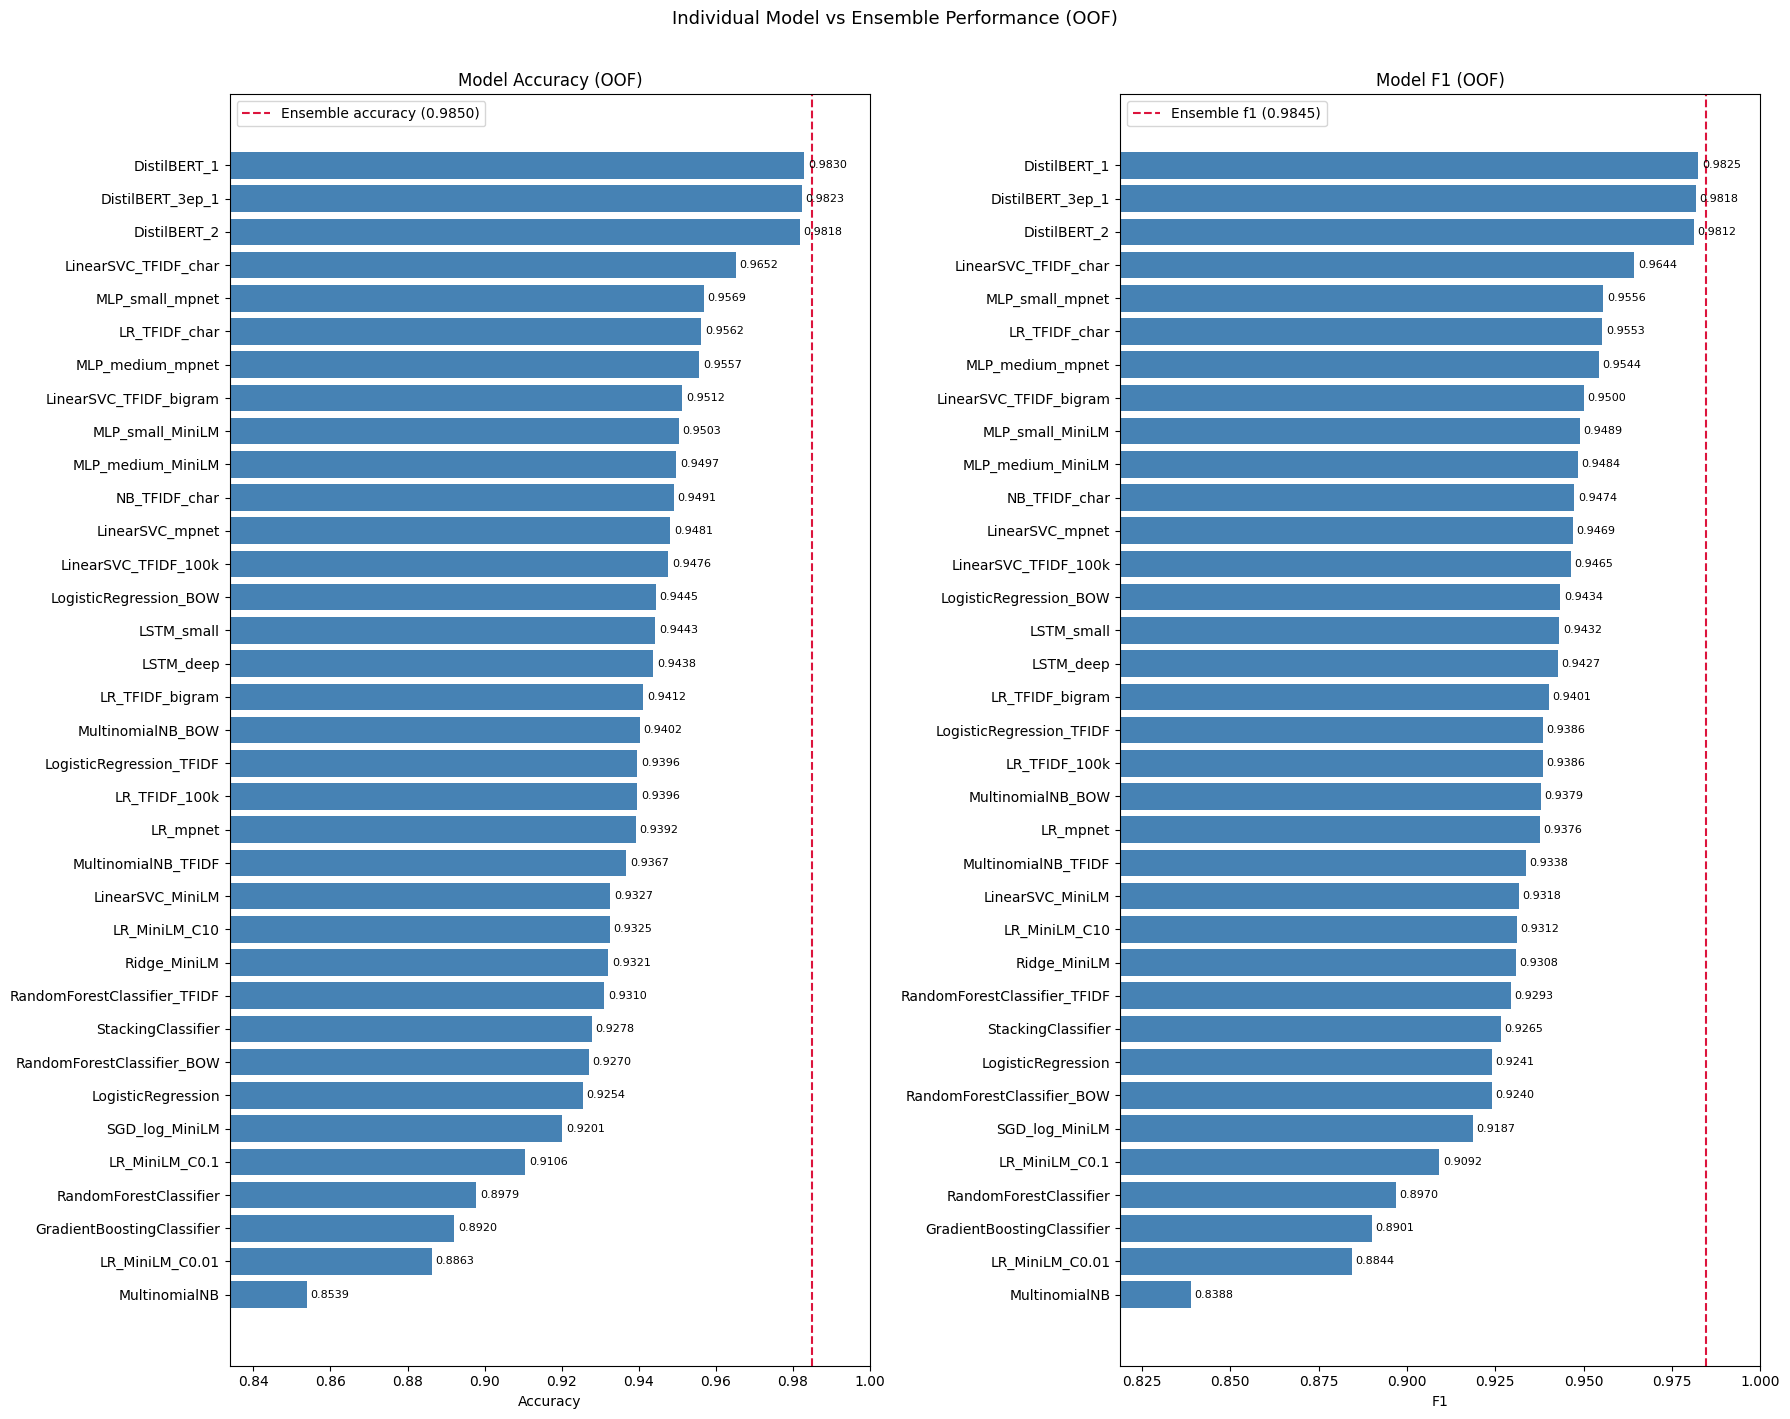

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# ── Compute metrics for each individual model ─────────────────

results = []
for i, name in enumerate(files):
    oof_probs = x_train[:, i]
    oof_preds = (oof_probs >= 0.5).astype(int)
    acc = accuracy_score(true, oof_preds)
    f1  = f1_score(true, oof_preds)
    results.append({"model": name, "accuracy": acc, "f1": f1})
    print(f"{name:45s} acc={acc:.4f}  f1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)

# ── Also print ensemble score for reference ───────────────────

oof_preds_ensemble = (meta.predict_proba(x_train)[:, 1] >= 0.5).astype(int)
ensemble_acc = accuracy_score(true, oof_preds_ensemble)
ensemble_f1  = f1_score(true, oof_preds_ensemble)
print(f"\n{'ENSEMBLE (LogReg meta)':45s} acc={ensemble_acc:.4f}  f1={ensemble_f1:.4f}")

# ── Plot ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(results) * 0.4)))

for ax, metric in zip(axes, ["accuracy", "f1"]):
    df = results_df.sort_values(metric, ascending=True)  # ascending so best is at top
    colors = ["steelblue"] * len(df)

    ax.barh(df["model"], df[metric], color=colors)

    # Ensemble reference line
    ensemble_val = ensemble_acc if metric == "accuracy" else ensemble_f1
    ax.axvline(ensemble_val, color="crimson", linestyle="--", linewidth=1.5,
               label=f"Ensemble {metric} ({ensemble_val:.4f})")

    # Value labels on bars
    for j, (val, label) in enumerate(zip(df[metric], df["model"])):
        ax.text(val + 0.001, j, f"{val:.4f}", va="center", fontsize=8)

    ax.set_xlabel(metric.capitalize())
    ax.set_title(f"Model {metric.capitalize()} (OOF)")
    ax.legend()
    xmin = max(0, df[metric].min() - 0.02)
    ax.set_xlim(xmin, min(1.0, df[metric].max() + 0.04))

plt.suptitle("Individual Model vs Ensemble Performance (OOF)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()